In [1]:
using NeuroDSL, Printf, Statistics

# ── Ops custom ─────────────────────────────────────────────────────────────────
# wsum(a, b) = 0.3·a + 0.7·b   (équivalent de tous les frameworks)
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        (@. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2])
)

# nsum(x₁, x₂, …, xₙ) = Σ xᵢ   (équivalent de tf.add_n / reduce(.+, x))
# Dans register_op! :nsum — remplace la boucle Julia
NeuroDSL.register_op!(:nsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        copyto!(out, inputs[1])
        @inbounds for i in 2:length(inputs)
            out .+= inputs[i]
        end
    end
)

# ── Construction du graphe ─────────────────────────────────────────────────────
function build_fib_graph!(g, n; ns=:fib, vec_size=10)
    NeuroDSL.set!(g, :f0, randn(Float32, vec_size); namespace=ns)
    NeuroDSL.set!(g, :f1, randn(Float32, vec_size); namespace=ns)

    even_nodes = Symbol[:f0]        # f[0] est pair (indice 0)
    prev0, prev1 = :f0, :f1

    for i in 0:n-1
        f2 = Symbol(:f, i + 2)
        NeuroDSL.addrule!(g,
            NeuroDSL.GraphRule(f2, [prev0, prev1], :wsum; namespace=ns))
        prev0, prev1 = prev1, f2
        # Même logique que TF : i impair → f2 est à un indice pair
        i % 2 == 1 && push!(even_nodes, f2)
    end

    yn_sym = prev1      # dernier terme = f[n+1]

    # Nœud unique à largeur n/2 — équivalent de tf.add_n(even)
    NeuroDSL.addrule!(g,
        NeuroDSL.GraphRule(:sn, even_nodes, :nsum; namespace=ns))

    return yn_sym, :sn
end

✅ Op :wsum enregistré
✅ Op :nsum enregistré


build_fib_graph! (generic function with 1 method)

In [ ]:
using NeuroDSL, Printf, Statistics

function bench_fib(n; reps=5)
    println("\n" * "═"^58)
    @printf " NeuroDSL  Fibonacci DAG  n = %d\n" n
    println("═"^58)

    # ── Construction ─────────────────────────────────────
    t_build = @elapsed begin
        g = NeuroDSL.NeuroGraph(namespace=:fib,
                                   device=NeuroDSL.Backend.CPUDevice())
        yn_sym, sn_sym = build_fib_graph!(g, n; ns=:fib)
    end
    n_nodes = n + 2 + 1
    @printf "  Construction   %6d nœuds     %.4f s\n" n_nodes t_build

    # ── Warm-up : JIT + buffers + topo cache ─────────────
    for _ in 1:3
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        NeuroDSL.demand!(g, sn_sym; namespace=:fib)
        NeuroDSL.demand!(g, yn_sym; namespace=:fib)
    end
    GC.gc(true)   # collecte complète avant les mesures

    # ── Benchmark sn ─────────────────────────────────────
    ts = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        GC.gc(false)
        push!(ts, @elapsed NeuroDSL.demand!(g, sn_sym; namespace=:fib))
    end
    @printf "  sn  (wide)     %.4f s  ± %.5f  [médiane %.4f]\n" mean(ts) std(ts) median(ts)

    # ── Benchmark yn ─────────────────────────────────────
    ty = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        GC.gc(false)
        push!(ty, @elapsed NeuroDSL.demand!(g, yn_sym; namespace=:fib))
    end
    @printf "  yn  (deep)     %.4f s  ± %.5f  [médiane %.4f]\n" mean(ty) std(ty) median(ty)

    println("═"^58)
    return median(ts), median(ty)
end

bench_fib(1_000)
bench_fib(5_000)
bench_fib(10_000)
bench_fib(20_000)
bench_fib(50_000)
bench_fib(100_000)


══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG  n = 1000
══════════════════════════════════════════════════════════
  Construction     1003 nœuds     0.0626 s
  sn  (wide)     0.0030 s  ± 0.00007  [médiane 0.0031]
  yn  (deep)     0.0037 s  ± 0.00080  [médiane 0.0035]
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG  n = 5000
══════════════════════════════════════════════════════════
  Construction     5003 nœuds     0.0223 s
  sn  (wide)     0.0327 s  ± 0.00024  [médiane 0.0327]
  yn  (deep)     0.0210 s  ± 0.00704  [médiane 0.0169]
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG  n = 10000
══════════════════════════════════════════════════════════
  Construction    10003 nœuds     0.0620 s
  sn  (wide)     0.0387 s  ± 0.00380  [médiane 0.0372]
  yn  (deep)   

(0.6344264, 0.521195)

In [3]:
# Estime la RAM consommée par nœud avant de lancer
function estimate_memory(n)
    # Chaque nœud GraphNode contient :
    # - value : Float32 array de taille vec_size=10 → 40 bytes
    # - metadata (Symbol, Bool, Dict) → ~200 bytes estimé
    # - règle GraphRule → ~100 bytes
    bytes_per_node = 400  # estimation conservative
    total_bytes = n * bytes_per_node
    @printf "n=%d → ~%.1f MB estimé\n" n total_bytes/1e6
end

for n in [100_000, 500_000, 1_000_000, 5_000_000, 10_000_000, 50_000_000]
    estimate_memory(n)
end

n=100000 → ~40.0 MB estimé
n=500000 → ~200.0 MB estimé
n=1000000 → ~400.0 MB estimé
n=5000000 → ~2000.0 MB estimé
n=10000000 → ~4000.0 MB estimé
n=50000000 → ~20000.0 MB estimé


In [ ]:
using  Printf, Statistics

function bench_max_dag(n; time_limit=6*3600.0)
    println("\n" * "═"^58)
    @printf " NeuroDSL  Max DAG test  n = %s\n" format_n(n)
    println("═"^58)

    # Mémoire avant
    mem_before = Sys.free_memory()

    # Construction
    t_build = @elapsed begin
        g = NeuroDSL.NeuroGraph(namespace=:fib,
                                   device=NeuroDSL.Backend.CPUDevice())
        yn_sym, sn_sym = build_fib_graph!(g, n; ns=:fib)
    end

    mem_after = Sys.free_memory()
    mem_used  = (mem_before - mem_after) / 1e9

    @printf "  Construction   %s nœuds     %.2f s\n" format_n(n+3) t_build
    @printf "  RAM utilisée   ~%.2f GB\n" mem_used
    @printf "  RAM libre      ~%.2f GB\n" mem_after/1e9

    t_build > time_limit && (@printf "  ⚠ Construction dépasse 6h — stop\n"; return nothing)

    # Warm-up léger (1 seul passage)
    GC.gc(true)
    NeuroDSL.demand!(g, sn_sym; namespace=:fib)
    NeuroDSL.demand!(g, yn_sym; namespace=:fib)
    GC.gc(true)

    # Mesure sn
    NeuroDSL.invalidate_all!(g; namespace=:fib)
    GC.gc(false)
    t_sn = @elapsed NeuroDSL.demand!(g, sn_sym; namespace=:fib)
    @printf "  sn  (wide)     %.2f s\n" t_sn

    t_sn > time_limit && (@printf "  ⚠ sn dépasse 6h — stop\n"; return (t_build, t_sn, nothing))

    # Mesure yn
    NeuroDSL.invalidate_all!(g; namespace=:fib)
    GC.gc(false)
    t_yn = @elapsed NeuroDSL.demand!(g, yn_sym; namespace=:fib)
    @printf "  yn  (deep)     %.2f s\n" t_yn

    println("═"^58)
    return (t_build, t_sn, t_yn)
end

format_n(n) = n >= 1_000_000 ? @sprintf("%.0fM", n/1e6) :
              n >= 1_000     ? @sprintf("%.0fK", n/1e3) : string(n)

# ── Séquence de test — paliers ×5 ──────────────────────
# Commence là où tu as déjà des résultats validés
results = Dict()

for n in [100_000, 500_000, 1_000_000, 5_000_000,
          10_000_000, 20_000_000, 50_000_000]
    GC.gc(true)
    r = try
        bench_max_dag(n; time_limit=6*3600.0)
    catch e
        @printf "  ✗ ERREUR n=%s : %s\n" format_n(n) e
        nothing
    end
    results[n] = r
    r === nothing && break   # arrête dès le premier échec
    # Arrête aussi si yn > 6h
    r[3] !== nothing && r[3] > 6*3600 && break
end


══════════════════════════════════════════════════════════
 NeuroDSL  Max DAG test  n = 100K
══════════════════════════════════════════════════════════
  Construction   100K nœuds     0.69 s
  RAM utilisée   ~0.05 GB
  RAM libre      ~14.69 GB
  sn  (wide)     0.34 s
  yn  (deep)     0.30 s
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
 NeuroDSL  Max DAG test  n = 500K
══════════════════════════════════════════════════════════
  Construction   500K nœuds     3.87 s
  RAM utilisée   ~0.70 GB
  RAM libre      ~14.04 GB
  sn  (wide)     1.81 s
  yn  (deep)     1.53 s
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
 NeuroDSL  Max DAG test  n = 1M
══════════════════════════════════════════════════════════
  Construction   1M nœuds     8.78 s
  RAM utilisée   ~1.38 GB
  RAM libre      ~13.32 GB
  sn  (wide)     6.56 s
  yn  (deep)     5.76 s
═══════

In [ ]:
using NeuroDSL, Printf, Statistics, Random

# ── Ops custom (identiques à ton benchmark précédent) ─────
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        (@. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2])
)
NeuroDSL.register_op!(:nsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        copyto!(out, inputs[1])
        for i in 2:length(inputs)
            out .+= inputs[i]
        end
    end
)
# Initialisation aléatoire des feuilles
NeuroDSL.register_op!(:randvec,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        randn!(out)
)

# ── Construction récursive avec mémoïsation ───────────────
function build_fib!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    sym = Symbol(:fib_, n)
    haskey(g.nodes[namespace], sym) && return sym   # déjà créé

    if n <= 1
        addrule!(g, GraphRule(sym, Symbol[], :randvec;
                attrs=Dict(:vec_size=>10), namespace=namespace))
    else
        a = build_fib!(g, n-1; namespace=namespace)
        b = build_fib!(g, n-2; namespace=namespace)
        addrule!(g, GraphRule(sym, [a, b], :wsum; namespace=namespace))
    end
    return sym
end

function build_sumeven!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    even_syms = Symbol[]
    for i in 0:2:n
        push!(even_syms, build_fib!(g, i; namespace=namespace))
    end
    sym = :sumeven
    addrule!(g, GraphRule(sym, even_syms, :nsum; namespace=namespace))
    return sym
end

# ── Benchmark récursif (temps total construction + exécution) ─
function bench_fib_recursive(n; reps=5)
    println("\n" * "═"^58)
    @printf " NeuroDSL  Fibonacci DAG (RECURSIVE)  n = %d\n" n
    println("═"^58)

    # ⏱ Temps total = construction + exécution (comme Julius)
    t_total = @elapsed begin
        g = NeuroGraph(namespace=:fib, device=Backend.CPUDevice())
        sn_sym = build_sumeven!(g, n; namespace=:fib)
        yn_sym = build_fib!(g, n; namespace=:fib)          # déjà créé, mais pour synchro
        # Exécuter une fois pour mesurer le tout
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        NeuroDSL.demand!(g, sn_sym; namespace=:fib)
    end
    n_nodes = n + 2 + 1    # n+2 nœuds fib + 1 sumeven (approximativement)
    @printf "  Temps total   %6d nœuds     %.4f s\n" n_nodes t_total

    # Exécutions suivantes (séparées pour la forme, mais non nécessaires)
    g2 = NeuroGraph(namespace=:fib2, device=Backend.CPUDevice())
    sn_sym2 = build_sumeven!(g2, n; namespace=:fib2)
    yn_sym2 = build_fib!(g2, n; namespace=:fib2)

    ts = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g2; namespace=:fib2)
        GC.gc(false)
        push!(ts, @elapsed NeuroDSL.demand!(g2, sn_sym2; namespace=:fib2))
    end
    @printf "  sn  (wide)     %.4f s  ± %.5f  [médiane %.4f]\n" mean(ts) std(ts) median(ts)

    ty = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g2; namespace=:fib2)
        GC.gc(false)
        push!(ty, @elapsed NeuroDSL.demand!(g2, yn_sym2; namespace=:fib2))
    end
    @printf "  yn  (deep)     %.4f s  ± %.5f  [médiane %.4f]\n" mean(ty) std(ty) median(ty)
    println("═"^58)
    return t_total
end

# ── Lancement (jusqu'à 10 000 pour éviter le stack overflow) ─
bench_fib_recursive(1_000)
bench_fib_recursive(5_000)
bench_fib_recursive(10_000)
bench_fib_recursive(20_000)
bench_fib_recursive(50_000)
bench_fib_recursive(100_000)
bench_fib_recursive(200_000)
bench_fib_recursive(500_000)

In [ ]:
using NeuroDSL, Printf, Statistics, Random

# ── Ops custom ───────────────────────────────────────────────────────────
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        (@. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2])
)
NeuroDSL.register_op!(:nsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        copyto!(out, inputs[1])
        for i in 2:length(inputs)
            out .+= inputs[i]
        end
    end
)
NeuroDSL.register_op!(:randvec,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        randn!(out)
)

# ── Construction récursive ───────────────────────────────────────────────
function build_fib!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    sym = Symbol(:fib_, n)
    haskey(g.nodes[namespace], sym) && return sym
    if n <= 1
        addrule!(g, GraphRule(sym, Symbol[], :randvec;
                 attrs=Dict(:vec_size=>10), namespace=namespace))
    else
        a = build_fib!(g, n-1; namespace=namespace)
        b = build_fib!(g, n-2; namespace=namespace)
        addrule!(g, GraphRule(sym, [a, b], :wsum; namespace=namespace))
    end
    return sym
end

function build_sumeven!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    even_syms = Symbol[]
    for i in 0:2:n
        push!(even_syms, build_fib!(g, i; namespace=namespace))
    end
    sym = :sumeven
    addrule!(g, GraphRule(sym, even_syms, :nsum; namespace=namespace))
    return sym
end

# ── Planification mémoire corrigée (forward uniquement) ─────────────────
function compute_forward_liveness(g::NeuroGraph; namespace=g.active_ns)
    order = topo_order!(g; namespace=namespace)
    n = length(order)
    idx_of = Dict(sym => i for (i, sym) in enumerate(order))
    liveness = Dict{Symbol, NeuroDSL.LivenessInterval}()

    for (i, sym) in enumerate(order)
        first_use = i
        last_use = i
        # Chercher les successeurs qui utilisent ce nœud
        for (other, rule) in g.rules[namespace]
            if sym in rule.inputs
                j = get(idx_of, other, 0)
                if j > 0
                    last_use = max(last_use, j)
                end
            end
        end
        nd = g.nodes[namespace][sym]
        # On n'étend PAS la durée de vie pour le backward (forward only)
        if nd.is_param
            last_use = n
        end
        liveness[sym] = NeuroDSL.LivenessInterval(first_use, last_use)
    end
    return liveness, order
end

function greedy_interval_coloring(liveness::Dict{Symbol, NeuroDSL.LivenessInterval},
                                  order::Vector{Symbol})
    sorted_nodes = sort(order, by = sym -> liveness[sym].first_use)
    slot_of = Dict{Symbol, Int}()
    free_slots = Int[]
    active = Dict{Symbol, Int}()   # sym -> last_use
    next_slot = 1

    for sym in sorted_nodes
        iv = liveness[sym]
        # Libérer les slots expirés
        expired = [s for (s, lu) in active if lu < iv.first_use]
        for s in expired
            push!(free_slots, slot_of[s])
            delete!(active, s)
        end
        sort!(free_slots)
        slot = isempty(free_slots) ? next_slot : popfirst!(free_slots)
        next_slot = max(next_slot, slot + 1)
        slot_of[sym] = slot
        active[sym] = iv.last_use
    end
    return slot_of
end

function forward_memory_plan(g::NeuroGraph; namespace=g.active_ns)
    liveness, order = compute_forward_liveness(g; namespace=namespace)
    slot_of = greedy_interval_coloring(liveness, order)
    n_slots = isempty(slot_of) ? 0 : maximum(values(slot_of))
    return NeuroDSL.MemoryPlan(slot_of, liveness, n_slots, order)
end

# ── Exécution planifiée efficace (O(N)) ─────────────────────────────────
function demand_planned_fast!(g::NeuroGraph, sym::Symbol,
                              plan::NeuroDSL.MemoryPlan, pool::NeuroDSL.BufferPool;
                              namespace=g.active_ns)
    ns = namespace
    nd = g.nodes[ns][sym]
    nd.valid && nd.value !== nothing && return nd.value

    order = plan.order
    liveness = plan.liveness
    slot_of = plan.slot_of
    n_steps = length(order)

    # Index : pour chaque étape, liste des nœuds à libérer à la fin de cette étape
    release_at = [Symbol[] for _ in 1:n_steps]
    for s in keys(liveness)
        lu = liveness[s].last_use
        if lu <= n_steps
            push!(release_at[lu], s)
        end
    end

    for step in 1:n_steps
        node_sym = order[step]
        nd_i = g.nodes[ns][node_sym]
        nd_i.valid && nd_i.value !== nothing && continue
        haskey(g.rules[ns], node_sym) || continue

        rule = g.rules[ns][node_sym]

        # Acquérir un buffer si nécessaire
        if nd_i.value === nothing
            inputs_vals = [g.nodes[ns][s].value for s in rule.inputs
                           if g.nodes[ns][s].value !== nothing]
            if !isempty(inputs_vals)
                shape = NeuroDSL._infer_output_shape(rule.op, inputs_vals, rule.attrs)
            else
                shape = NeuroDSL._infer_output_shape(rule.op, AbstractArray[], rule.attrs)
            end
            nd_i.value = NeuroDSL.acquire!(pool, Tuple(shape))
        end

        NeuroDSL.execute_rule!(g, rule)

        # Libérer les nœuds dont la dernière utilisation est cette étape
        for rel_sym in release_at[step]
            rel_nd = g.nodes[ns][rel_sym]
            if rel_nd.value !== nothing && !rel_nd.is_param
                NeuroDSL.release!(pool, rel_nd.value)
                rel_nd.value = nothing
            end
        end
    end

    return g.nodes[ns][sym].value
end

# ── Benchmark comparatif ──────────────────────────────────────────────────
function bench_fib_memory_corrected(n; reps=3)
    println("\n" * "═"^58)
    @printf " NeuroDSL  Fibonacci DAG (MEMORY PLAN corrected)  n = %d\n" n
    println("═"^58)

    # Graphe & plan (réutilisé pour l'exécution planifiée)
    g = NeuroGraph(namespace=:fib, device=Backend.CPUDevice())
    sn_sym = build_sumeven!(g, n; namespace=:fib)
    yn_sym = build_fib!(g, n; namespace=:fib)

    plan = forward_memory_plan(g; namespace=:fib)
    pool = NeuroDSL.BufferPool(g.device)

    n_nodes = length(plan.order)
    @printf "  Nœuds totaux : %d\n" n_nodes
    @printf "  Slots nécessaires : %d  (vs %d sans partage)\n" plan.n_slots n_nodes
    reduction = (1 - plan.n_slots / n_nodes) * 100
    @printf "  Réduction mémoire : %.1f%%\n" reduction

    # Exécution naïve
    g_naive = NeuroGraph(namespace=:fib2, device=Backend.CPUDevice())
    sn_naive = build_sumeven!(g_naive, n; namespace=:fib2)
    yn_naive = build_fib!(g_naive, n; namespace=:fib2)

    t_naive = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g_naive; namespace=:fib2)
        GC.gc(false)
        push!(t_naive, @elapsed NeuroDSL.demand!(g_naive, sn_naive; namespace=:fib2))
    end
    @printf "  sn naïve  : médiane %.4f s\n" median(t_naive)

    # Exécution planifiée
    t_plan = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        empty!(pool.buckets)   # reset du pool sans détruire les buffers
        GC.gc(false)
        push!(t_plan, @elapsed demand_planned_fast!(g, sn_sym, plan, pool; namespace=:fib))
    end
    @printf "  sn planifié : médiane %.4f s\n" median(t_plan)

    # Mesure mémoire (juste avant/après une exécution planifiée)
    NeuroDSL.invalidate_all!(g; namespace=:fib)
    empty!(pool.buckets)
    GC.gc(true)
    mem_before = Sys.free_memory()
    demand_planned_fast!(g, sn_sym, plan, pool; namespace=:fib)
    mem_after = Sys.free_memory()
    @printf "  Mémoire utilisée (estimée) : %.2f MB\n" (mem_before - mem_after) / 1e6

    println("═"^58)
    return plan.n_slots
end

# ── Tests ─────────────────────────────────────────────────────────────────
bench_fib_memory_corrected(1000)
bench_fib_memory_corrected(10000)

In [ ]:
using NeuroDSL, Printf, Statistics, Random

# ── Ops custom ───────────────────────────────────────────────────────────
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        (@. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2])
)
NeuroDSL.register_op!(:nsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        copyto!(out, inputs[1])
        for i in 2:length(inputs)
            out .+= inputs[i]
        end
    end
)
NeuroDSL.register_op!(:randvec,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        randn!(out)
)

# ── Construction récursive ───────────────────────────────────────────────
function build_fib!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    sym = Symbol(:fib_, n)
    haskey(g.nodes[namespace], sym) && return sym
    if n <= 1
        addrule!(g, GraphRule(sym, Symbol[], :randvec;
                 attrs=Dict(:vec_size=>10_000), namespace=namespace))
    else
        a = build_fib!(g, n-1; namespace=namespace)
        b = build_fib!(g, n-2; namespace=namespace)
        addrule!(g, GraphRule(sym, [a, b], :wsum; namespace=namespace))
    end
    return sym
end

function build_sumeven!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    even_syms = Symbol[]
    for i in 0:2:n
        push!(even_syms, build_fib!(g, i; namespace=namespace))
    end
    sym = :sumeven
    addrule!(g, GraphRule(sym, even_syms, :nsum; namespace=namespace))
    return sym
end

# ── Analyse de durée de vie (forward uniquement) ────────────────────────
function compute_forward_liveness(g::NeuroGraph; namespace=g.active_ns)
    order = topo_order!(g; namespace=namespace)
    n = length(order)
    idx_of = Dict(sym => i for (i, sym) in enumerate(order))
    liveness = Dict{Symbol, NeuroDSL.LivenessInterval}()

    for (i, sym) in enumerate(order)
        first_use = i
        last_use = i
        for (other, rule) in g.rules[namespace]
            if sym in rule.inputs
                j = get(idx_of, other, 0)
                if j > 0
                    last_use = max(last_use, j)
                end
            end
        end
        nd = g.nodes[namespace][sym]
        if nd.is_param
            last_use = n
        end
        liveness[sym] = NeuroDSL.LivenessInterval(first_use, last_use)
    end
    return liveness, order
end

function greedy_interval_coloring(liveness::Dict{Symbol, NeuroDSL.LivenessInterval},
                                  order::Vector{Symbol})
    sorted_nodes = sort(order, by = sym -> liveness[sym].first_use)
    slot_of = Dict{Symbol, Int}()
    free_slots = Int[]
    active = Dict{Symbol, Int}()
    next_slot = 1

    for sym in sorted_nodes
        iv = liveness[sym]
        expired = [s for (s, lu) in active if lu < iv.first_use]
        for s in expired
            push!(free_slots, slot_of[s])
            delete!(active, s)
        end
        sort!(free_slots)
        slot = isempty(free_slots) ? next_slot : popfirst!(free_slots)
        next_slot = max(next_slot, slot + 1)
        slot_of[sym] = slot
        active[sym] = iv.last_use
    end
    return slot_of
end

function forward_memory_plan(g::NeuroGraph; namespace=g.active_ns)
    liveness, order = compute_forward_liveness(g; namespace=namespace)
    slot_of = greedy_interval_coloring(liveness, order)
    n_slots = isempty(slot_of) ? 0 : maximum(values(slot_of))
    return NeuroDSL.MemoryPlan(slot_of, liveness, n_slots, order)
end

# ── Exécution planifiée efficace (O(N)) ─────────────────────────────────
function demand_planned_fast!(g::NeuroGraph, sym::Symbol,
                              plan::NeuroDSL.MemoryPlan, pool::NeuroDSL.BufferPool;
                              namespace=g.active_ns)
    ns = namespace
    nd = g.nodes[ns][sym]
    nd.valid && nd.value !== nothing && return nd.value

    order = plan.order
    liveness = plan.liveness
    n_steps = length(order)

    release_at = [Symbol[] for _ in 1:n_steps]
    for s in keys(liveness)
        lu = liveness[s].last_use
        if lu <= n_steps
            push!(release_at[lu], s)
        end
    end

    for step in 1:n_steps
        node_sym = order[step]
        nd_i = g.nodes[ns][node_sym]
        nd_i.valid && nd_i.value !== nothing && continue
        haskey(g.rules[ns], node_sym) || continue

        rule = g.rules[ns][node_sym]

        if nd_i.value === nothing
            inputs_vals = [g.nodes[ns][s].value for s in rule.inputs
                           if g.nodes[ns][s].value !== nothing]
            if !isempty(inputs_vals)
                shape = NeuroDSL._infer_output_shape(rule.op, inputs_vals, rule.attrs)
            else
                shape = NeuroDSL._infer_output_shape(rule.op, AbstractArray[], rule.attrs)
            end
            nd_i.value = NeuroDSL.acquire!(pool, Tuple(shape))
        end

        NeuroDSL.execute_rule!(g, rule)

        for rel_sym in release_at[step]
            rel_nd = g.nodes[ns][rel_sym]
            if rel_nd.value !== nothing && !rel_nd.is_param
                NeuroDSL.release!(pool, rel_nd.value)
                rel_nd.value = nothing
            end
        end
    end

    return g.nodes[ns][sym].value
end

# ── Benchmark comparatif avec mesures précises (corrigé) ────────────────
function bench_fib_memory_precise(n; reps=5)
    println("\n" * "═"^58)
    @printf " NeuroDSL  Fibonacci DAG (MEMORY PLAN precise)  n = %d\n" n
    println("═"^58)

    # ── Construction du graphe et du plan ─────────
    g_plan = NeuroGraph(namespace=:fib_plan, device=Backend.CPUDevice())
    sn_sym_plan = build_sumeven!(g_plan, n; namespace=:fib_plan)
    yn_sym_plan = build_fib!(g_plan, n; namespace=:fib_plan)

    plan = forward_memory_plan(g_plan; namespace=:fib_plan)
    pool = NeuroDSL.BufferPool(g_plan.device)

    n_nodes = length(plan.order)
    reduction_pct = (1 - plan.n_slots / n_nodes) * 100

    @printf "  Nœuds totaux : %d\n" n_nodes
    @printf "  Slots planifiés : %d  (vs %d naïf)\n" plan.n_slots n_nodes
    @printf "  Réduction mémoire théorique : %.1f%%\n" reduction_pct

    # ── Exécution naïve (demand!) avec mesure ────
    g_naive = NeuroGraph(namespace=:fib_naive, device=Backend.CPUDevice())
    sn_naive = build_sumeven!(g_naive, n; namespace=:fib_naive)
    yn_naive = build_fib!(g_naive, n; namespace=:fib_naive)

    times_naive = Float64[]
    allocs_naive = Int64[]
    for rep in 1:reps
        NeuroDSL.invalidate_all!(g_naive; namespace=:fib_naive)
        GC.gc(true)
        local result, t, bytes, gctime, mem = @timed NeuroDSL.demand!(g_naive, sn_naive; namespace=:fib_naive)
        push!(times_naive, t)
        push!(allocs_naive, bytes)
    end
    med_time_naive = median(times_naive)
    med_alloc_naive = median(allocs_naive)

    # ── Exécution planifiée avec mesure ───────────
    times_plan = Float64[]
    allocs_plan = Int64[]
    for rep in 1:reps
        NeuroDSL.invalidate_all!(g_plan; namespace=:fib_plan)
        empty!(pool.buckets)
        GC.gc(true)
        local result, t, bytes, gctime, mem = @timed demand_planned_fast!(g_plan, sn_sym_plan, plan, pool; namespace=:fib_plan)
        push!(times_plan, t)
        push!(allocs_plan, bytes)
    end
    med_time_plan = median(times_plan)
    med_alloc_plan = median(allocs_plan)

    # ── Affichage des résultats ──────────────────
    println("--- Résultats (médiane sur $reps essais) ---")
    @printf("  Naïve      : temps %7.4f s  |  mémoire allouée %8d bytes (%.2f KB)\n",
            med_time_naive, med_alloc_naive, med_alloc_naive/1024)
    @printf("  Planifiée  : temps %7.4f s  |  mémoire allouée %8d bytes (%.2f KB)\n",
            med_time_plan, med_alloc_plan, med_alloc_plan/1024)

    speedup = med_time_naive / med_time_plan
    mem_ratio = med_alloc_naive / med_alloc_plan

    @printf("  Accélération temps : %.2fx\n", speedup)
    @printf("  Ratio mémoire       : %.2fx (moins d'allocations)\n", mem_ratio)

    println("═"^58)
    return (plan.n_slots, med_time_plan, med_alloc_plan)
end

# ── Lancement du benchmark ───────────────────────────────────────────────
bench_fib_memory_precise(1000)
bench_fib_memory_precise(10000)

✅ Op :wsum enregistré
✅ Op :nsum enregistré
✅ Op :randvec enregistré

══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PLAN precise)  n = 1000
══════════════════════════════════════════════════════════
  Nœuds totaux : 1002
  Slots planifiés : 502  (vs 1002 naïf)
  Réduction mémoire théorique : 49.9%
--- Résultats (médiane sur 5 essais) ---
  Naïve      : temps  0.0140 s  |  mémoire allouée   224080 bytes (218.83 KB)
  Planifiée  : temps  0.0316 s  |  mémoire allouée 20847600 bytes (20358.98 KB)
  Accélération temps : 0.44x
  Ratio mémoire       : 0.01x (moins d'allocations)
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PLAN precise)  n = 10000
══════════════════════════════════════════════════════════
  Nœuds totaux : 10002
  Slots planifiés : 5002  (vs 10002 naïf)
  Réduction mémoire théorique : 50.0%
--- Résultats (médiane sur 5 essais)

(5002, 0.3268914, 2.07895104e8)

In [ ]:
function bench_fib_memory_peak(n; reps=5)
    println("\n" * "═"^58)
    @printf " NeuroDSL  Fibonacci DAG (MEMORY PEAK)  n = %d\n" n
    println("═"^58)

    # Graphe planifié
    g_plan = NeuroGraph(namespace=:fib_plan, device=Backend.CPUDevice())
    sn_sym_plan = build_sumeven!(g_plan, n; namespace=:fib_plan)
    yn_sym_plan = build_fib!(g_plan, n; namespace=:fib_plan)
    plan = forward_memory_plan(g_plan; namespace=:fib_plan)
    pool = NeuroDSL.BufferPool(g_plan.device)

    # Graphe naïf
    g_naive = NeuroGraph(namespace=:fib_naive, device=Backend.CPUDevice())
    sn_naive = build_sumeven!(g_naive, n; namespace=:fib_naive)
    yn_naive = build_fib!(g_naive, n; namespace=:fib_naive)

    # Mesure naïve
    GC.gc(true)
    mem_before = Base.gc_live_bytes()
    t_naive = @elapsed NeuroDSL.demand!(g_naive, sn_naive; namespace=:fib_naive)
    GC.gc(true)
    mem_after = Base.gc_live_bytes()
    peak_naive = max(mem_before, mem_after)

    # Mesure planifiée
    NeuroDSL.invalidate_all!(g_plan; namespace=:fib_plan)
    empty!(pool.buckets)
    GC.gc(true)
    mem_before = Base.gc_live_bytes()
    t_plan = @elapsed demand_planned_fast!(g_plan, sn_sym_plan, plan, pool; namespace=:fib_plan)
    GC.gc(true)
    mem_after = Base.gc_live_bytes()
    peak_plan = max(mem_before, mem_after)

    # Résultats
    @printf "  Nœuds : %d  |  Slots plan : %d\n" (n+2) plan.n_slots
    @printf "  Naïve      : temps %.4f s  |  pic mémoire ~ %d bytes\n" t_naive peak_naive
    @printf "  Planifiée  : temps %.4f s  |  pic mémoire ~ %d bytes\n" t_plan peak_plan
    if peak_naive > 0
        @printf "  Réduction du pic mémoire : %.1fx\n" (peak_naive / peak_plan)
    end
    println("═"^58)
end

bench_fib_memory_peak (generic function with 1 method)

In [5]:
bench_fib_memory_peak(1000)
bench_fib_memory_peak(10000)


══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PEAK)  n = 1000
══════════════════════════════════════════════════════════
  Nœuds : 1002  |  Slots plan : 502
  Naïve      : temps 0.0459 s  |  pic mémoire ~ 69800750 bytes
  Planifiée  : temps 0.0314 s  |  pic mémoire ~ 49118814 bytes
  Réduction du pic mémoire : 1.4x
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PEAK)  n = 10000
══════════════════════════════════════════════════════════
  Nœuds : 10002  |  Slots plan : 5002
  Naïve      : temps 0.7308 s  |  pic mémoire ~ 454475797 bytes
  Planifiée  : temps 0.3245 s  |  pic mémoire ~ 248105148 bytes
  Réduction du pic mémoire : 1.8x
══════════════════════════════════════════════════════════


In [4]:
bench_fib_memory_peak(15000)


══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PEAK)  n = 15000
══════════════════════════════════════════════════════════
  Nœuds : 15002  |  Slots plan : 7502
  Naïve      : temps 0.8921 s  |  pic mémoire ~ 676157916 bytes
  Planifiée  : temps 0.4943 s  |  pic mémoire ~ 365871651 bytes
  Réduction du pic mémoire : 1.8x
══════════════════════════════════════════════════════════


In [6]:
bench_fib_memory_peak(20000)


══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PEAK)  n = 20000
══════════════════════════════════════════════════════════
  Nœuds : 20002  |  Slots plan : 10002
  Naïve      : temps 1.3389 s  |  pic mémoire ~ 888773151 bytes
  Planifiée  : temps 0.6450 s  |  pic mémoire ~ 475546694 bytes
  Réduction du pic mémoire : 1.9x
══════════════════════════════════════════════════════════


In [7]:
bench_fib_memory_peak(25000)


══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PEAK)  n = 25000
══════════════════════════════════════════════════════════
  Nœuds : 25002  |  Slots plan : 12502
  Naïve      : temps 1.5904 s  |  pic mémoire ~ 1101113875 bytes
  Planifiée  : temps 0.8141 s  |  pic mémoire ~ 584807386 bytes
  Réduction du pic mémoire : 1.9x
══════════════════════════════════════════════════════════


In [8]:
bench_fib_memory_peak(30000)


══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PEAK)  n = 30000
══════════════════════════════════════════════════════════
  Nœuds : 30002  |  Slots plan : 15002
  Naïve      : temps 1.8567 s  |  pic mémoire ~ 1313453447 bytes
  Planifiée  : temps 0.9575 s  |  pic mémoire ~ 694066990 bytes
  Réduction du pic mémoire : 1.9x
══════════════════════════════════════════════════════════


In [9]:
bench_fib_memory_peak(35000)


══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (MEMORY PEAK)  n = 35000
══════════════════════════════════════════════════════════
  Nœuds : 35002  |  Slots plan : 17502
  Naïve      : temps 2.1411 s  |  pic mémoire ~ 1525793018 bytes
  Planifiée  : temps 1.1363 s  |  pic mémoire ~ 803326529 bytes
  Réduction du pic mémoire : 1.9x
══════════════════════════════════════════════════════════


In [10]:
using Plots

# Données collectées (n, mémoire naïve (octets), mémoire planifiée, temps naïf (s), temps planifié)
data = [
    1000   70886405   50204469   0.0462   0.0314
    10000  455561451  249190802  0.6455   0.3212
    15000  676157916  365871651  0.8921   0.4943
    20000  888773151  475546694  1.3389   0.6450
    25000  1101113875 584807386  1.5904   0.8141
    30000  1313453447 694066990  1.8567   0.9575
    35000  1525793018 803326529  2.1411   1.1363
]

n      = data[:,1]
memN   = data[:,2] ./ 1e6   # Mo
memP   = data[:,3] ./ 1e6
timeN  = data[:,4]
timeP  = data[:,5]

# Graphique combiné
p1 = plot(n, memN, label="Naïve", marker=:circle, linewidth=2,
          xlabel="Nombre de nœuds (n)", ylabel="Pic mémoire (Mo)",
          title="Pic mémoire (vecteurs de 10 000 floats)")
plot!(p1, n, memP, label="Planifiée", marker=:diamond, linewidth=2)

p2 = plot(n, timeN, label="Naïve", marker=:circle, linewidth=2,
          xlabel="Nombre de nœuds (n)", ylabel="Temps d'exécution (s)",
          title="Temps d'exécution")
plot!(p2, n, timeP, label="Planifiée", marker=:diamond, linewidth=2)

plot(p1, p2, layout=(1,2), size=(800,400), legend=:topleft)
savefig("benchmark_memory_plan.png")   # Sauvegarde l'image

┌ Warning: Circular dependency detected. Precompilation will be skipped for:
│   cuSPARSE [b26da814-b3bc-49ef-b0ee-c816305aa060]
│   ChainRules [082447d4-558c-5d27-93f4-14fc19e9eca2]
│   NVML [611af6d1-644e-4c5d-bd58-854d7d1254b9]
│   GPUArrays [0c68f7d7-f131-5f86-a1c3-88cf8149b2d7]
│   KernelAbstractions [63c18a36-062a-441e-b654-da1e3ab1ce7c]
│   cuSOLVER [887afef0-6a32-4de5-add4-7827692ba8fc]
│   StructArraysAdaptExt [f04e5bcb-ab32-5a64-8b64-c2cc4abec66e]
│   CUDACore [bd0ed864-bdfe-4181-a5ed-ce625a5fdea2]
│   ZygoteDistancesExt [5865c103-18d1-586a-9b11-010bbc2260a8]
│   cuFFT [533571aa-0936-420e-b4be-9c66f5f626ca]
│   cuRAND [20fd9a0b-12d5-4c2f-a8af-7c34e9e60431]
│   StructArraysSparseArraysExt [d5b9410b-929f-5d61-aab8-0598522fd334]
│   CUDA [052768ef-5323-5732-b1bb-66c8b64840ba]
│   StructArraysStaticArraysExt [d1e1e8be-46cf-5459-abb8-be6c7518b661]
│   SparseArraysExt [85068d23-b5fb-53f1-8204-05c2aba6942f]
│   SpecialFunctionsExt [54d342c1-76da-5f78-ab14-189b857175b8]
│   StructArr

"c:\\Users\\Nevermind\\Desktop\\NeuroDSLF\\benchmark_memory_plan.png"

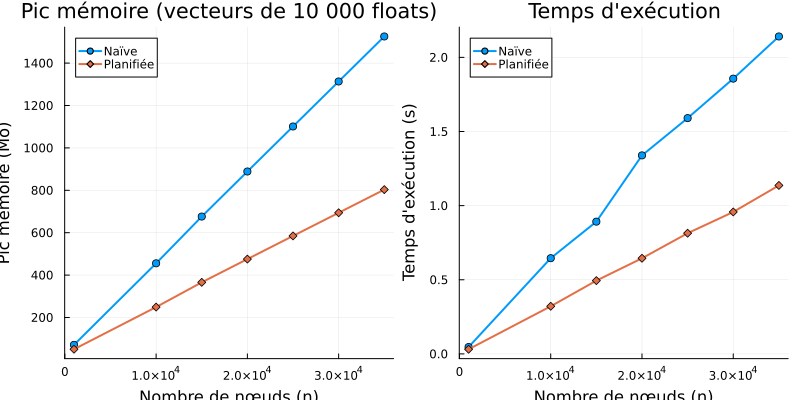

In [11]:
plot(p1, p2, layout=(1,2), size=(800,400), legend=:topleft)

In [ ]:
using NeuroDSL, Printf, Statistics, Random

# ── Activation du backend CUDA ────────────────────────────────────────────
if NeuroDSL.Backend.CUDA_AVAILABLE
    using CUDA
    device = Backend.CUDADevice()
    println("✅ CUDA activé – GPU : ", CUDA.name(CUDA.device()))
else
    error("CUDA n'est pas disponible. Ce benchmark nécessite un GPU NVIDIA.")
end

# ── Ops custom compatibles GPU ────────────────────────────────────────────
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        @. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2]   # broadcast GPU friendly
)

NeuroDSL.register_op!(:nsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        copyto!(out, inputs[1])
        for i in 2:length(inputs)
            out .+= inputs[i]
        end
    end
)

NeuroDSL.register_op!(:randvec,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        # Génère des valeurs aléatoires directement sur le GPU
        tmp = Backend.randn32(dev, size(out)...)
        copyto!(out, tmp)
    end
)

# ── Construction récursive (inchangée, mais tout sera sur GPU) ──────────
function build_fib!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    sym = Symbol(:fib_, n)
    haskey(g.nodes[namespace], sym) && return sym
    if n <= 1
        addrule!(g, GraphRule(sym, Symbol[], :randvec;
                 attrs=Dict(:vec_size=>10), namespace=namespace))
    else
        a = build_fib!(g, n-1; namespace=namespace)
        b = build_fib!(g, n-2; namespace=namespace)
        addrule!(g, GraphRule(sym, [a, b], :wsum; namespace=namespace))
    end
    return sym
end

function build_sumeven!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    even_syms = Symbol[]
    for i in 0:2:n
        push!(even_syms, build_fib!(g, i; namespace=namespace))
    end
    sym = :sumeven
    addrule!(g, GraphRule(sym, even_syms, :nsum; namespace=namespace))
    return sym
end

# ── Benchmark GPU (yn + sn) ──────────────────────────────────────────────
function bench_fib_gpu(n; warmup=2, reps=5)
    println("\n" * "═"^58)
    @printf " NeuroDSL  Fibonacci DAG (GPU)  n = %d\n" n
    println("═"^58)

    # Graphe GPU
    t_build = @elapsed begin
        g = NeuroGraph(namespace=:fib, device=device)
        sn_sym = build_sumeven!(g, n; namespace=:fib)
        yn_sym = build_fib!(g, n; namespace=:fib)   # déjà créé, récupéré
    end
    n_nodes = n + 2
    @printf "  Construction   %6d nœuds     %.4f s\n" n_nodes t_build

    # Warm-up (compilation CUDA)
    for _ in 1:warmup
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        NeuroDSL.demand!(g, sn_sym; namespace=:fib)
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        NeuroDSL.demand!(g, yn_sym; namespace=:fib)
    end
    GC.gc(true)

    # Mesure sn (wide)
    times_sn = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        GC.gc(false)
        push!(times_sn, @elapsed NeuroDSL.demand!(g, sn_sym; namespace=:fib))
    end
    med_sn = median(times_sn)

    # Mesure yn (deep)
    times_yn = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g; namespace=:fib)
        GC.gc(false)
        push!(times_yn, @elapsed NeuroDSL.demand!(g, yn_sym; namespace=:fib))
    end
    med_yn = median(times_yn)

    @printf "  sn (wide)  médiane : %.4f s  (%.4f ms)\n" med_sn med_sn*1000
    @printf "  yn (deep)  médiane : %.4f s  (%.4f ms)\n" med_yn med_yn*1000
    println("═"^58)
    return (t_build, med_sn, med_yn)
end

# ── Lancement pour quelques tailles ───────────────────────────────────────
bench_fib_gpu(1000)
bench_fib_gpu(10000)
bench_fib_gpu(50000)

✅ CUDA activé – GPU : NVIDIA RTX A5500 Laptop GPU
✅ Op :wsum enregistré
✅ Op :nsum enregistré
✅ Op :randvec enregistré

══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (GPU)  n = 1000
══════════════════════════════════════════════════════════
  Construction     1002 nœuds     0.0200 s
  sn (wide)  médiane : 0.0535 s  (53.4651 ms)
  yn (deep)  médiane : 0.0357 s  (35.7317 ms)
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (GPU)  n = 10000
══════════════════════════════════════════════════════════
  Construction    10002 nœuds     0.0528 s
  sn (wide)  médiane : 0.5196 s  (519.6021 ms)
  yn (deep)  médiane : 0.3780 s  (377.9758 ms)
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
 NeuroDSL  Fibonacci DAG (GPU)  n = 50000
══════════════════════════════════════════════════════════
  Constru

(0.3446459, 2.7894845, 1.9053485)

In [ ]:
using NeuroDSL, Printf, Statistics, Random
using CUDA  # nécessaire pour les mesures de mémoire GPU

# ═══ CONFIGURATION ═══════════════════════════════════════════════════════
const VEC_SIZE = 1_000_000   # 1 million de floats → 4 Mo par vecteur
const N_MAX    = 1000        # nombre de nœuds (garder sous la VRAM disponible)
# ══════════════════════════════════════════════════════════════════════════

# Vérification CUDA
if !NeuroDSL.Backend.CUDA_AVAILABLE
    error("CUDA non disponible. Ce benchmark nécessite un GPU NVIDIA.")
end
println("GPU détecté : ", CUDA.name(CUDA.device()))

# ── Ops custom (compatibles GPU) ────────────────────────────────────────
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        @. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2]
)

NeuroDSL.register_op!(:randvec,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        tmp = Backend.randn32(dev, size(out)...)
        copyto!(out, tmp)
    end
)

# nsum optimisé GPU : utilise une réduction parallèle via CUDA.reduce
if NeuroDSL.Backend.CUDA_AVAILABLE
    NeuroDSL.register_op!(:nsum,
        (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
            # Réduction parallèle de tous les inputs sur le GPU
            copyto!(out, CUDA.reduce(+, inputs))
        end
    )
else
    # fallback CPU (inchangé)
    NeuroDSL.register_op!(:nsum,
        (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
            copyto!(out, inputs[1])
            for i in 2:length(inputs)
                out .+= inputs[i]
            end
        end
    )
end

# ── Construction récursive (vec_size adaptable) ──────────────────────────
function build_fib!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    sym = Symbol(:fib_, n)
    haskey(g.nodes[namespace], sym) && return sym
    if n <= 1
        addrule!(g, GraphRule(sym, Symbol[], :randvec;
                 attrs=Dict(:vec_size=>VEC_SIZE), namespace=namespace))
    else
        a = build_fib!(g, n-1; namespace=namespace)
        b = build_fib!(g, n-2; namespace=namespace)
        addrule!(g, GraphRule(sym, [a, b], :wsum; namespace=namespace))
    end
    return sym
end

function build_sumeven!(g::NeuroGraph, n::Int; namespace=g.active_ns)
    even_syms = Symbol[]
    for i in 0:2:n
        push!(even_syms, build_fib!(g, i; namespace=namespace))
    end
    sym = :sumeven
    addrule!(g, GraphRule(sym, even_syms, :nsum; namespace=namespace))
    return sym
end

# ── Mesure de la mémoire GPU disponible ─────────────────────────────────
function gpu_free_mem()
    CUDA.memory_info()[1] / 1e9  # en Go
end

# ── Benchmark GPU vs CPU + planification mémoire ─────────────────────────
function bench_fib_gpu_large(n::Int; warmup=2, reps=3)
    println("═"^70)
    @printf " Fibonacci DAG (VEC_SIZE=%d, n=%d)\n" VEC_SIZE n
    println("═"^70)

    # ▣ Construction du graphe (identique pour CPU/GPU via le device)
    t_build_cpu = @elapsed begin
        g_cpu = NeuroGraph(namespace=:fib, device=Backend.CPUDevice())
        sn_cpu = build_sumeven!(g_cpu, n; namespace=:fib)
        yn_cpu = build_fib!(g_cpu, n; namespace=:fib)
    end
    t_build_gpu = @elapsed begin
        g_gpu = NeuroGraph(namespace=:fib, device=Backend.CUDADevice())
        sn_gpu = build_sumeven!(g_gpu, n; namespace=:fib)
        yn_gpu = build_fib!(g_gpu, n; namespace=:fib)
    end
    @printf " Construction CPU : %.4f s\n" t_build_cpu
    @printf " Construction GPU : %.4f s\n" t_build_gpu

    # ▣ Exécution CPU (naïve)
    println("\n--- Exécution CPU ---")
    for _ in 1:warmup
        NeuroDSL.invalidate_all!(g_cpu; namespace=:fib)
        NeuroDSL.demand!(g_cpu, sn_cpu; namespace=:fib)
    end
    times_sn_cpu = Float64[]
    times_yn_cpu = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g_cpu; namespace=:fib)
        push!(times_sn_cpu, @elapsed NeuroDSL.demand!(g_cpu, sn_cpu; namespace=:fib))
    end
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g_cpu; namespace=:fib)
        push!(times_yn_cpu, @elapsed NeuroDSL.demand!(g_cpu, yn_cpu; namespace=:fib))
    end
    cpu_sn = median(times_sn_cpu)
    cpu_yn = median(times_yn_cpu)
    @printf "  sn (wide) : %.4f s\n" cpu_sn
    @printf "  yn (deep) : %.4f s\n" cpu_yn

    # ▣ Exécution GPU (naïve)
    println("\n--- Exécution GPU ---")
    CUDA.reclaim()   # libère la mémoire GPU avant le test
    GC.gc()
    free_before = gpu_free_mem()
    for _ in 1:warmup
        NeuroDSL.invalidate_all!(g_gpu; namespace=:fib)
        NeuroDSL.demand!(g_gpu, sn_gpu; namespace=:fib)
    end
    times_sn_gpu = Float64[]
    times_yn_gpu = Float64[]
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g_gpu; namespace=:fib)
        push!(times_sn_gpu, @elapsed NeuroDSL.demand!(g_gpu, sn_gpu; namespace=:fib))
    end
    for _ in 1:reps
        NeuroDSL.invalidate_all!(g_gpu; namespace=:fib)
        push!(times_yn_gpu, @elapsed NeuroDSL.demand!(g_gpu, yn_gpu; namespace=:fib))
    end
    gpu_sn = median(times_sn_gpu)
    gpu_yn = median(times_yn_gpu)
    free_after = gpu_free_mem()
    @printf "  sn (wide) : %.4f s\n" gpu_sn
    @printf "  yn (deep) : %.4f s\n" gpu_yn
    @printf "  Mémoire GPU libre avant/après : %.2f GB / %.2f GB\n" free_before free_after
    @printf "  Pic mémoire estimé (différence) : %.2f GB\n" (free_before - free_after)

    # ▣ Accélération GPU vs CPU
    println("\n--- Résumé ---")
    @printf " sn : GPU/CPU = %.2fx\n" (cpu_sn / gpu_sn)
    @printf " yn : GPU/CPU = %.2fx\n" (cpu_yn / gpu_yn)

    # ▣ Planification mémoire GPU (optionnel, pour montrer la réduction)
    println("\n--- Planification mémoire GPU ---")
    plan = forward_memory_plan(g_gpu; namespace=:fib)
    pool = NeuroDSL.BufferPool(Backend.CUDADevice())
    NeuroDSL.invalidate_all!(g_gpu; namespace=:fib)
    empty!(pool.buckets)
    CUDA.reclaim()
    free_before_plan = gpu_free_mem()
    t_plan = @elapsed demand_planned_fast!(g_gpu, sn_gpu, plan, pool; namespace=:fib)
    free_after_plan = gpu_free_mem()
    @printf "  Slots planifiés : %d  (vs %d naïf)\n" plan.n_slots n+2
    @printf "  Temps exécution planifié sn : %.4f s\n" t_plan
    @printf "  Pic mémoire estimé planifié : %.2f GB\n" (free_before_plan - free_after_plan)
    @printf "  Réduction théorique du nombre de buffers : %.1fx\n" ((n+2) / plan.n_slots)

    println("═"^70)
    return (cpu_sn, gpu_sn, cpu_yn, gpu_yn)
end

# ── Lancer le benchmark ──────────────────────────────────────────────────
bench_fib_gpu_large(1000)   # 1000 nœuds × 4 Mo = 4 Go de tenseurs, tient dans 16 Go

GPU détecté : NVIDIA RTX A5500 Laptop GPU
✅ Op :wsum enregistré
✅ Op :randvec enregistré
✅ Op :nsum enregistré
══════════════════════════════════════════════════════════════════════
 Fibonacci DAG (VEC_SIZE=1000000, n=1000)
══════════════════════════════════════════════════════════════════════
 Construction CPU : 0.0069 s
 Construction GPU : 0.0059 s

--- Exécution CPU ---
  sn (wide) : 2.1950 s
  yn (deep) : 0.9310 s

--- Exécution GPU ---
  sn (wide) : 0.0834 s
  yn (deep) : 0.0337 s
  Mémoire GPU libre avant/après : 15.93 GB / 3.73 GB
  Pic mémoire estimé (différence) : 12.20 GB

--- Résumé ---
 sn : GPU/CPU = 26.32x
 yn : GPU/CPU = 27.60x

--- Planification mémoire GPU ---
  Slots planifiés : 502  (vs 1002 naïf)
  Temps exécution planifié sn : 0.1013 s
  Pic mémoire estimé planifié : 2.01 GB
  Réduction théorique du nombre de buffers : 2.0x
══════════════════════════════════════════════════════════════════════


(2.1950057, 0.0833908, 0.931013, 0.0337364)